In [1]:
import pandas as pd

dataset = pd.read_csv("../datasets/penguins.csv")

feature_names = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
]
target_name = "Body Mass (g)"

dataset = dataset[feature_names + [target_name]].dropna(axis="rows", how="any")
dataset = dataset.sample(frac=1, random_state=0).reset_index(drop=True)
data, target = dataset[feature_names], dataset[target_name]

# Preparation step

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt_reg = DecisionTreeRegressor(random_state=0)
rf_reg = RandomForestRegressor(random_state=0)

In [4]:
from sklearn.model_selection import cross_validate

cv_dt_reg = cross_validate(
    dt_reg,
    data,
    target,cv=10,
    return_train_score=True
)
cv_rf_reg = cross_validate(
    rf_reg,
    data,
    target,cv=10,
    return_train_score=True
)

# Q1

In [13]:
cv_dt_reg['test_score']

array([0.59650558, 0.66957713, 0.7193112 , 0.8184209 , 0.6242818 ,
       0.72483157, 0.53090702, 0.51655398, 0.58421785, 0.49038086])

In [7]:
cv_rf_reg['test_score']

array([0.78812533, 0.77436104, 0.88871396, 0.84661427, 0.78043644,
       0.85771461, 0.79185662, 0.73543268, 0.76485281, 0.8077531 ])

# Q2

In [8]:
rf_5 = RandomForestRegressor(n_estimators=5, random_state=0)
rf_100 = RandomForestRegressor(n_estimators=100, random_state=0)

cv_rf_5 = cross_validate(
    rf_5,
    data,
    target,cv=10,
    return_train_score=True
)
cv_rf_100 = cross_validate(
    rf_100,
    data,
    target,cv=10,
    return_train_score=True
)

In [14]:
cv_rf_100['test_score'] > cv_rf_5['test_score']

array([ True,  True,  True,  True, False,  True,  True,  True,  True,
        True])

# Q3

In [15]:
import numpy as np
n_estimators = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1_000])

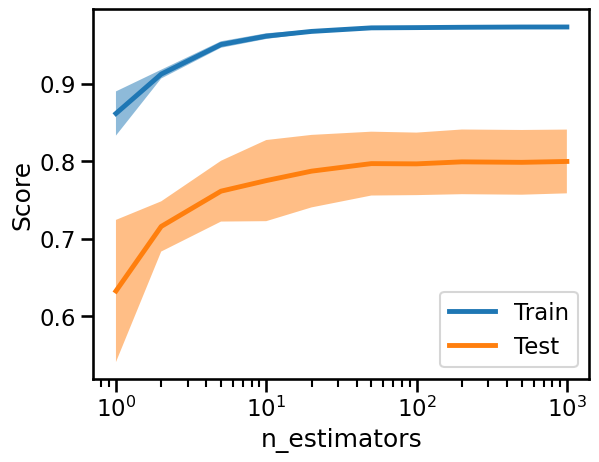

In [18]:
from sklearn.model_selection import ValidationCurveDisplay

vcd = ValidationCurveDisplay.from_estimator(
    RandomForestRegressor(random_state=0),
    data,
    target,
    param_name="n_estimators",
    param_range=n_estimators,
    n_jobs=2
)

# Q4

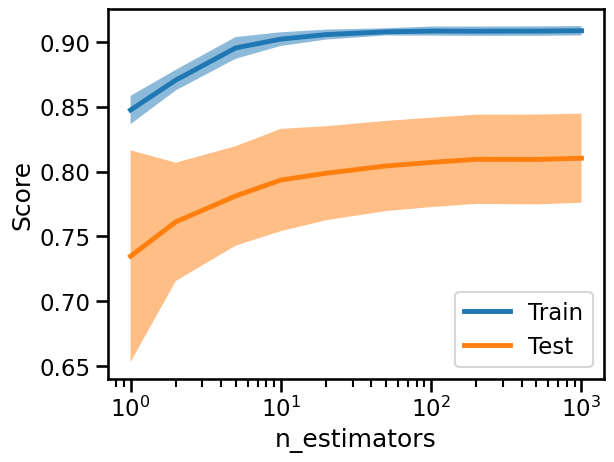

In [19]:
vcd_depth_5 = ValidationCurveDisplay.from_estimator(
    RandomForestRegressor(max_depth=5, random_state=0),
    data,
    target,
    param_name="n_estimators",
    param_range=n_estimators,
    n_jobs=2
)

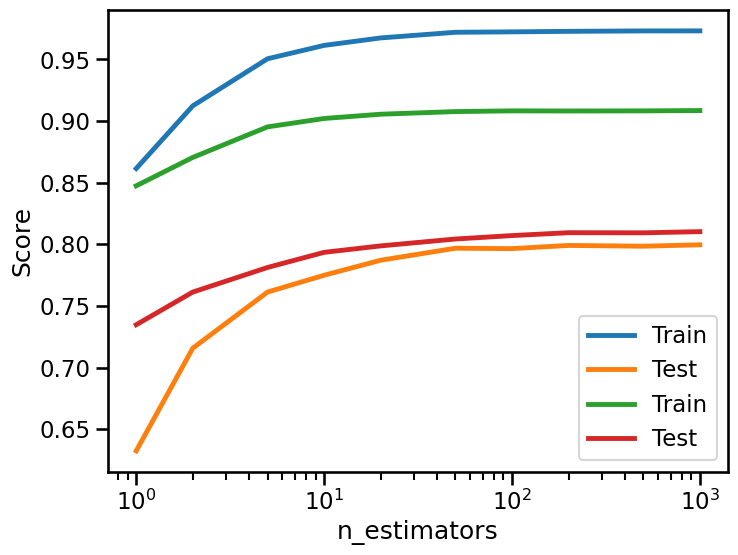

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

vcd.plot(ax=ax, std_display_style=None)
vcd_depth_5.plot(ax=ax, std_display_style=None)

# Middle steps

In [25]:
rf_1_tree = RandomForestRegressor(n_estimators=1, random_state=0)
cv_results_tree = cross_validate(
    rf_1_tree, data, target, cv=10, return_train_score=True
)
cv_results_tree["train_score"]

array([0.83120264, 0.83309064, 0.83195043, 0.84834224, 0.85790323,
       0.86235297, 0.84791111, 0.85183089, 0.82241954, 0.85045978])

In [26]:
tree = DecisionTreeRegressor(random_state=0)
cv_results_tree = cross_validate(
    tree, data, target, cv=10, return_train_score=True
)
cv_results_tree["train_score"]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

# Q5

The single tree in the random forest is trained using a bootstrap of the training set and not the training set itself (because *bootstrap=True* by default)

# Q6

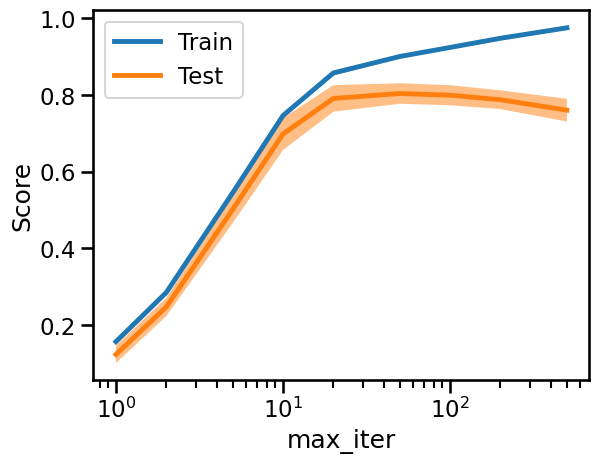

In [28]:
from sklearn.ensemble import HistGradientBoostingRegressor

max_iters = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])

vcd_hgbt_reg = ValidationCurveDisplay.from_estimator(
    HistGradientBoostingRegressor(random_state=0),
    data,
    target,
    param_name="max_iter",
    param_range=max_iters,
    n_jobs=2
)

# Remarks - ???